## Step 1: Set Up and Load the Data

In [3]:
%pip install openpyxl -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Online Retail dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Check data types and missing values
print(df.info())
print('\nMissing values')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None

Missing values
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Step 2: Explore and Clean the Raw Data

In [6]:
# Start with the original row count
print(f'Original rows: {len(df)}')

# Remove rows with missing customerID
df_clean = df.dropna(subset=['CustomerID'])
print (f'After removing the null CustomerID: {len(df_clean)}')

# Remove cancellations (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {len(df_clean)}')

# Remove rows with non-positive Quantity or UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f'After removing invalid quantities/prices: {len(df_clean)}')

Original rows: 541909
After removing the null CustomerID: 406829
After removing cancellations: 397924
After removing invalid quantities/prices: 397884


In [7]:
# Create Revenue column
df_clean = df_clean.copy()
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Convert InvoiceDate to datetime and create InvoiceMonth
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Verify
print(f'\nCleaned dataset shape: {df_clean.shape}')
print(f'\nNull values: \n{df_clean.isnull().sum()}')
print(f'\nRevenue statistics: \n{df_clean['Revenue'].describe()}')


Cleaned dataset shape: (397884, 10)

Null values: 
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Revenue         0
InvoiceMonth    0
dtype: int64

Revenue statistics: 
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


## Step 3: Build the Cohort Retention Matrix

In [8]:
# Find each customer's first purchse month (cohort month)
cohort_month = df_clean.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
cohort_month.columns = ['CustomerID', 'CohortMonth']

# Merge cohort month back to the main dataframe
df_clean = df_clean.merge(cohort_month, on='CustomerID')

In [9]:
# Calculate cohort index (months since first purchase)
df_clean['CohortIndex'] = (
    df_clean['InvoiceMonth'].apply(lambda x: x.ordinal) -
    df_clean['CohortMonth'].apply(lambda x: x.ordinal)
    )

In [10]:
# Count unique customers per cohort per period
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'CustomerCount']

# Pivot to create the cohort table
cohort_table = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerCount')

# Calculate retention: divide each row by its first column (period 0)
cohort_size = cohort_table.iloc[:, 0]
retention_matrix = cohort_table.divide(cohort_size, axis=0)

# Display first 5 rows and columns
print('Retention Matrix (first 5 cohorts, first 5 periods):')
print(retention_matrix.iloc[:5, :5])

Retention Matrix (first 5 cohorts, first 5 periods):
CohortIndex    0         1         2         3         4
CohortMonth                                             
2010-12      1.0  0.366102  0.323164  0.384181  0.362712
2011-01      1.0  0.220624  0.266187  0.230216  0.321343
2011-02      1.0  0.186842  0.186842  0.284211  0.271053
2011-03      1.0  0.150442  0.252212  0.199115  0.223451
2011-04      1.0  0.213333  0.203333  0.210000  0.196667


## Step 4: Visualize Retention with a Heatmap

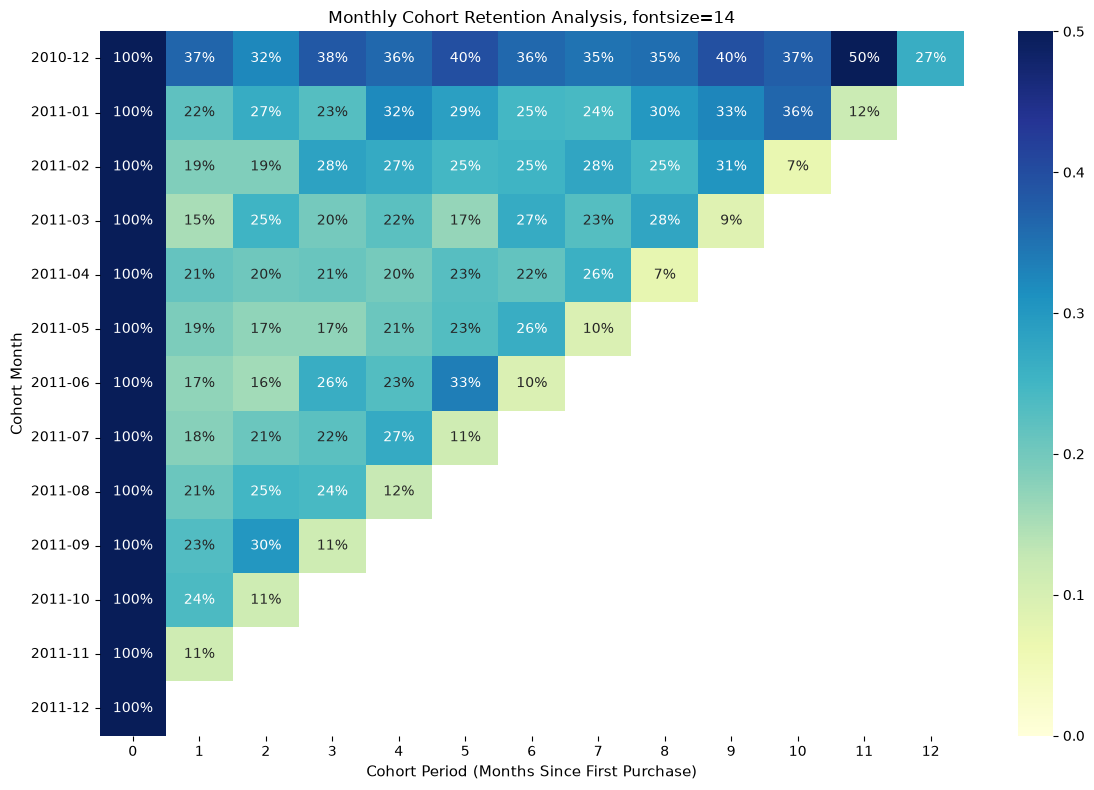

In [11]:
# Create the retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    vmin=0,
    vmax=0.5
)
plt.title('Monthly Cohort Retention Analysis, fontsize=14')
plt.xlabel('Cohort Period (Months Since First Purchase)', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Testing the Left-Censoring Hypothesis

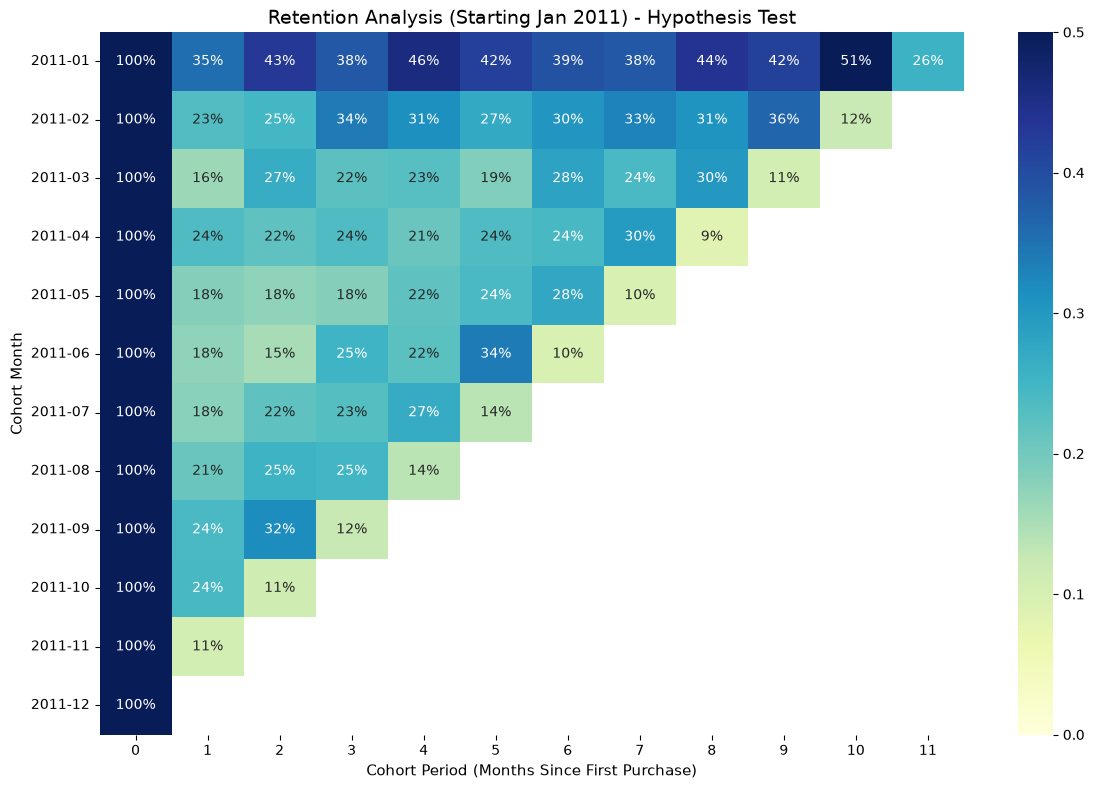

In [12]:
# Filter out the December 2010 data
df_test = df_clean[df_clean['InvoiceDate'] >= '2011-01-01'].copy()

# Recalculate the NEW first purchase month (Cohort Month)
cohort_month_test = df_test.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
cohort_month_test.columns = ['CustomerID', 'CohortMonth']

# Drop the old CohortMonth from df_test before merging the new one
df_test = df_test.drop(columns=['CohortMonth'], errors='ignore')

# Merge the NEW first purchase month (Cohort Month)
df_test = df_test.merge(cohort_month_test, on='CustomerID', how='left')

# Calculate the Cohort Index
df_test['CohortIndex'] = (
    df_test['InvoiceMonth'].apply(lambda x: x.ordinal) -
    df_test['CohortMonth'].apply(lambda x: x.ordinal)
)

# Count unique customers and Pivot
cohort_data_test = df_test.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_table_test = cohort_data_test.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Calculate Retention
cohort_size_test = cohort_table_test.iloc[:, 0]
retention_matrix_test = cohort_table_test.divide(cohort_size_test, axis=0)

# Visualize the new Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_matrix_test,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    vmin=0,
    vmax=0.5
)
plt.title('Retention Analysis (Starting Jan 2011) - Hypothesis Test', fontsize=14)
plt.xlabel('Cohort Period (Months Since First Purchase)', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: Business Recommendation

In [13]:
# Extract key numbers for the recommendation (Excluding the left-censored first row)
avg_retention_month1 = retention_matrix.iloc[1:, 1].mean()
avg_retention_month6 = retention_matrix.iloc[1:, 6].mean()
best_cohort_idx = retention_matrix.iloc[1:, 3].idxmax()
best_cohort_rate = retention_matrix.iloc[1:, 3].max()

print(f"Average retention at month 1: {avg_retention_month1:.1%}")
print(f"Average retention at month 6: {avg_retention_month6:.1%}")
print(f"Best cohort at month 3: {best_cohort_idx} ({best_cohort_rate:.1%})")

Average retention at month 1: 19.2%
Average retention at month 6: 22.4%
Best cohort at month 3: 2011-02 (28.4%)


## Step 6: Customer Segmentation by Purchase Frequency

In [14]:
# Count unique invoices per customer
customer_orders = df_clean.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'OrderCount']

# Define segments based on purchase frequency
def segment_customer(order_count):
    if order_count == 1:
        return 'One-Time'
    elif order_count <= 4:
        return 'Repeat'
    else:
        return 'VIP'

customer_orders['Segment'] = customer_orders['OrderCount'].apply(segment_customer)

# Calculate revenue per customer
customer_revenue = df_clean.groupby('CustomerID')['Revenue'].sum().reset_index()
customer_orders = customer_orders.merge(customer_revenue, on='CustomerID')

# Aggregate by segment
segment_summary = customer_orders.groupby('Segment').agg(
    CustomerCount=('CustomerID', 'count'),
    TotalRevenue=('Revenue', 'sum')
).reset_index()

segment_summary['RevenuePercent'] = segment_summary['TotalRevenue'] / segment_summary['TotalRevenue'].sum() * 100
segment_summary['CustomerPercent'] = segment_summary['CustomerCount'] / segment_summary['CustomerCount'].sum() * 100

print(segment_summary[['Segment', 'CustomerPercent', 'RevenuePercent']].to_string(index=False))

 Segment  CustomerPercent  RevenuePercent
One-Time        34.416782        6.915986
  Repeat        39.903181       21.871738
     VIP        25.680037       71.212276


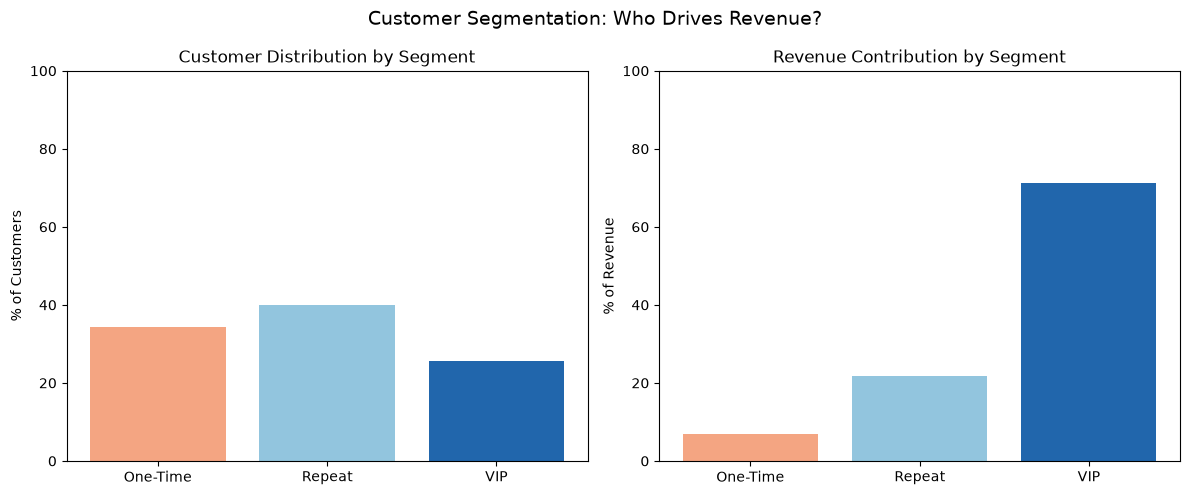


Key Insight: VIP customers (25.7% of customers) generate 71.2% of total revenue.


In [15]:
# Visualization: side-by-side bar charts
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: customer distribution
ax[0].bar(segment_summary['Segment'], segment_summary['CustomerPercent'], color=['#f4a582', '#92c5de', '#2166ac'])
ax[0].set_title('Customer Distribution by Segment', fontsize=12)
ax[0].set_ylabel('% of Customers')
ax[0].set_ylim(0, 100)

# Right chart: revenue distribution
ax[1].bar(segment_summary['Segment'], segment_summary['RevenuePercent'], color=['#f4a582', '#92c5de', '#2166ac'])
ax[1].set_title('Revenue Contribution by Segment', fontsize=12)
ax[1].set_ylabel('% of Revenue')
ax[1].set_ylim(0, 100)

plt.suptitle('Customer Segmentation: Who Drives Revenue?', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nKey Insight: VIP customers ({segment_summary[segment_summary['Segment']=='VIP']['CustomerPercent'].values[0]:.1f}% of customers) "
      f"generate {segment_summary[segment_summary['Segment']=='VIP']['RevenuePercent'].values[0]:.1f}% of total revenue.")